# This notebook covers how to use the Stack model to generate embeddings for cells in a user-provided AnnData.

The notebook assumes that the Stack model has been installed, using e.g. pip or uv install. It additionally assumes that relevant packages (e.g. scanpy, anndata, huggingface_hub etc) are already installed.

## Import packages

In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import os, sys

## Download the example checkpoint from HuggingFace

In [ ]:
from huggingface_hub import snapshot_download

repo_id = "arcinstitute/Stack-Large"
target_dir = "tutorial-embed-model"

if os.path.exists(target_dir) and os.listdir(target_dir):
    raise SystemExit(f"'{target_dir}' already exists and is not empty.")

snapshot_download(
    repo_id=repo_id,
    repo_type="model",
    revision="main",
    local_dir=target_dir,
    local_dir_use_symlinks=False,  
    resume_download=True,
)

print(f"Downloaded to ./{target_dir}")

In [3]:
# Download tabula sapiens data

! wget https://datasets.cellxgene.cziscience.com/d6761a21-e226-434f-9370-fbcc7e549aa0.h5ad -O tutorial-embed-data/lung.h5ad

--2025-12-12 01:00:03--  https://datasets.cellxgene.cziscience.com/d6761a21-e226-434f-9370-fbcc7e549aa0.h5ad
Resolving datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)... 13.225.143.79, 13.225.143.33, 13.225.143.98, ...
Connecting to datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)|13.225.143.79|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3206851888 (3.0G) [binary/octet-stream]
Saving to: ‘tutorial-embed-data/lung.h5ad’

tutorial-embed-data  51%[=========>          ]   1.53G  3.33MB/s    in 7m 16s  

2025-12-12 01:07:19 (3.60 MB/s) - Read error at byte 1646197474/3206851888 (Connection reset by peer). Retrying.

--2025-12-12 01:07:20--  (try: 2)  https://datasets.cellxgene.cziscience.com/d6761a21-e226-434f-9370-fbcc7e549aa0.h5ad
Connecting to datasets.cellxgene.cziscience.com (datasets.cellxgene.cziscience.com)|13.225.143.79|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 3206

Here for illustration, we simply input the entire data (ordered by donor column) to the model. For more advanced use, we may split the data by sample columns (e.g. donor, condition) then feed data to the model, finally concatenate them.

In [13]:
adata = sc.read_h5ad('tutorial-embed-data/lung.h5ad')
sorted_indices = np.argsort(adata.obs['donor_id'].values, kind='stable')
adata = adata[sorted_indices, :].copy()
adata.write('tutorial-embed-data/lung_ordered.h5ad')

In [14]:
! stack-embedding --checkpoint "tutorial-embed-model/bc_large.ckpt" \
--adata "tutorial-embed-data/lung_ordered.h5ad" \
--genelist "tutorial-embed-model/basecount_1000per_15000max.pkl" --gene-name-col feature_name --batch-size 16 \
--output "tutorial-embed-data/lung_ordered.npy"

[KeOps] Warning : CUDA was detected, but driver API could not be initialized. Switching to CPU only.
INFO:stack.model_loading:Loading model from tutorial-embed-model/bc_large.ckpt
/home/mingze/shiftab/state-ICL/src/stack/model_loading.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full

Note: When there are redundant gene names, stack dataloader loads the last shown gene with the same name. If this is not the intended behavior, some preprocessing of the data is needed.

In [15]:
adata.obsm['stack-embed'] = np.load('tutorial-embed-data/lung_ordered.npy')

Finally, the embedding can be used for downstream analyses just like other embeddings. Our extensive evaluations in the manuscript show the advantage of Stack embeddings over alternative foundation models or models trained from scratch.

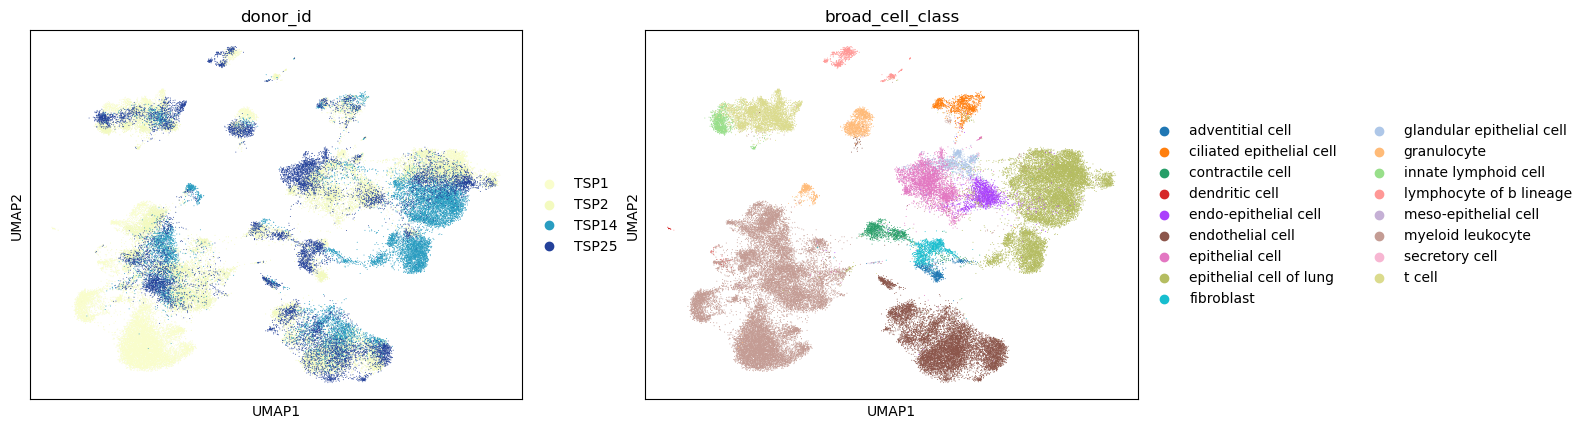

In [16]:
sc.pp.neighbors(adata,use_rep='stack-embed')
sc.tl.umap(adata)
sc.pl.umap(adata,color=['donor_id','broad_cell_class'])

Stack reveals fine-grained cell subtypes within data.

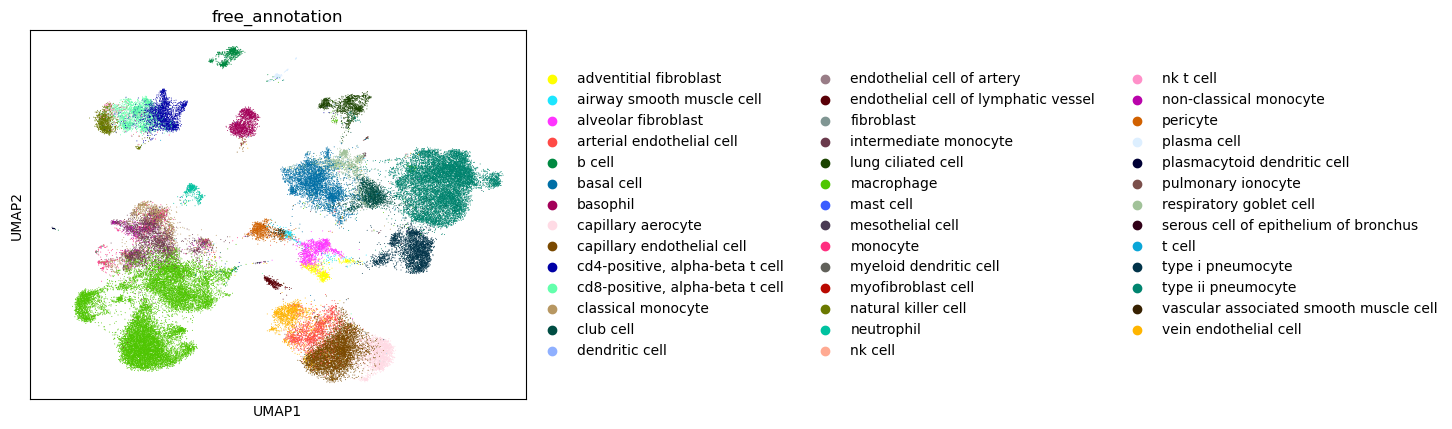

In [18]:
sc.pl.umap(adata,color=['free_annotation'])

Alternatively, we could use inline command (instead of CLI) to generate Stack embeddings. 

In [19]:
from stack.model_loading import load_model_from_checkpoint
model = load_model_from_checkpoint("tutorial-embed-model/bc_large.ckpt")

embeddings, _ = model.get_latent_representation(
    adata_path="tutorial-embed-data/lung_ordered.h5ad",
    genelist_path="hvg/basecount_1000per_15000max.pkl",
    gene_name_col='feature_name',
    batch_size=16,            
    num_workers=4            
)
embeddings

[KeOps] Warning : CUDA was detected, but driver API could not be initialized. Switching to CPU only.


/home/mingze/shiftab/state-ICL/src/stack/model_loading.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path_obj, map_location=device)

array([[-1.0577067e+00,  1.2824783e+00, -8.7215833e-02, ...,
         1.6814174e-01, -7.0379108e-01, -7.3187405e-01],
       [-2.3385818e+00,  1.7310480e+00,  8.8880157e-01, ...,
        -2.3923817e-01, -5.3139347e-01,  3.9351451e-01],
       [-1.5694022e+00,  1.7827749e+00,  5.8080828e-01, ...,
         1.6119337e-03, -5.9142023e-01,  3.1272419e-02],
       ...,
       [-8.1504577e-01,  1.4400125e+00,  1.8184973e-01, ...,
        -5.4747224e-02,  1.6330967e-02, -5.8790338e-01],
       [-7.2312152e-01,  2.6197818e-01,  1.7648489e-03, ...,
        -7.1969134e-01, -3.2975861e-01, -6.9474792e-01],
       [-7.8625768e-01,  4.7500652e-01, -2.0246414e-02, ...,
        -8.5588127e-01, -3.2196596e-01, -4.0951750e-01]],
      shape=(65847, 1600), dtype=float32)